# **Modeling and Evaluation - Cluster Analysis**

## Objectives

* Fit and evaluate a cluster model to group similar AI job profiles.
* Understand the profile for each cluster.

## Inputs

* `outputs/datasets/cleaned/TrainSet.csv`
* `outputs/datasets/cleaned/TestSet.csv`

## Outputs

* `outputs/ml_pipeline/cluster_analysis/v1/pipeline_cluster.pkl` — fitted cluster pipeline
* `outputs/ml_pipeline/cluster_analysis/v1/TrainSet.csv` — training data used for clustering
* `outputs/ml_pipeline/cluster_analysis/v1/clusters_profile.csv` — cluster profile summary
* `outputs/ml_pipeline/cluster_analysis/v1/clusters_silhouette.png` — silhouette plot
* `outputs/ml_pipeline/cluster_analysis/v1/features_define_cluster.png` — feature importance chart

## Imports

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import joblib
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Encoding
from feature_engine.encoding import CountFrequencyEncoder, OneHotEncoder

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# PCA
from sklearn.decomposition import PCA

# ML algorithm
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import silhouette_score, silhouette_samples

from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

---

# Change working directory

We need to change the working directory from its current folder to its parent folder.

* We access the current directory with `os.getcwd()`

In [2]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\chahi\\Desktop\\vscode-project\\the-ai-salary-index\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory.

* `os.path.dirname()` gets the parent directory
* `os.chdir()` defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\chahi\\Desktop\\vscode-project\\the-ai-salary-index'

---

# Load Data

In [5]:
df = pd.concat([
    pd.read_csv("outputs/datasets/cleaned/TrainSet.csv"),
    pd.read_csv("outputs/datasets/cleaned/TestSet.csv")
], ignore_index=True)

print(df.shape)
df.head(3)

(14701, 14)


,job_title,salary_usd,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,benefits_score,company_name
0,Machine Learning Engineer,177700,EX,PT,United Kingdom,M,United Kingdom,100,"Kubernetes, SQL, Python",PhD,14,Retail,8.2,Quantum Computing Inc
1,Principal Data Scientist,226559,EX,PT,South Korea,L,Argentina,50,"R, Python, Azure, SQL",PhD,11,Consulting,8.0,Future Systems
2,Research Scientist,109363,SE,CT,Singapore,S,Singapore,100,"Deep Learning, Java, Python",Associate,6,Energy,7.9,Predictive Systems


We drop columns not useful for clustering:

* `salary_usd` ” target variable (including it would cause leakage)
* `required_skills` ” high-cardinality free-text column (nearly one unique value per row)
* `company_name` ” only 16 unique values, adds no generalizable signal

In [6]:
df = df.drop(['salary_usd', 'required_skills', 'company_name'], axis=1)

print(df.shape)
print(df.dtypes)
df.head(3)

(14701, 11)
job_title              object
experience_level       object
employment_type        object
company_location       object
company_size           object
employee_residence     object
remote_ratio            int64
education_required     object
years_experience        int64
industry               object
benefits_score        float64
dtype: object


,job_title,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score
0,Machine Learning Engineer,EX,PT,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2
1,Principal Data Scientist,EX,PT,South Korea,L,Argentina,50,PhD,11,Consulting,8.0
2,Research Scientist,SE,CT,Singapore,S,Singapore,100,Associate,6,Energy,7.9


---

# Cluster Pipeline with all data

## Custom Encoder for Ordinal Variables

We create a custom transformer that applies meaningful ordinal mappings, matching the encoding established in the Feature Engineering notebook:

* `experience_level`: EN=0, MI=1, SE=2, EX=3
* `education_required`: Associate=0, Bachelor=1, Master=2, PhD=3
* `company_size`: S=0, M=1, L=2

In [7]:
sys.path.insert(0, '.')
from src.machine_learning.custom_transformers import (
    OrdinalMappingEncoder
)

## ML Cluster Pipeline

The pipeline uses encoding that matches the Feature Engineering notebook:

| Variable | Encoding | Rationale |
|---|---|---|
| `experience_level`, `education_required`, `company_size` | Ordinal mapping | These have a natural order |
| `employment_type` | One-hot encoding | Nominal, 4 categories |
| `job_title`, `company_location`, `employee_residence`, `industry` | Frequency encoding | High-cardinality nominal variables |

Key design decisions:
- **No `SmartCorrelatedSelection`** — PCA handles correlation naturally by compressing correlated features into shared components
- **`PCA(n_components=0.95)`** — keeps 95% of variance, automatically selects the right number of components. This ensures experience features get equal weight alongside geography
- **`StandardScaler`** before PCA — normalizes all features to the same scale

In [8]:
def PipelineCluster(n_components=0.95, n_clusters=3):
    pipeline_base = Pipeline([
        # Step 1: Encode ordinal variables with meaningful order
        ("OrdinalMappingEncoder", OrdinalMappingEncoder(mappings={
            'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
            'education_required': {
                'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
            'company_size': {'S': 0, 'M': 1, 'L': 2},
        })),

        # Step 2: One-hot encode employment_type (nominal, 4 categories)
        ("OneHotEncoder", OneHotEncoder(
            variables=['employment_type'],
            drop_last=True)),

        # Step 3: Frequency encode high-cardinality nominal variables
        ("FrequencyEncoder", CountFrequencyEncoder(
            encoding_method='frequency',
            variables=[
                'job_title', 'company_location',
                'employee_residence', 'industry'])),

        # Step 4: Scale all features so no group dominates by magnitude
        ("scaler", StandardScaler()),

        # Step 5: PCA — blend all features into balanced components
        ("PCA", PCA(n_components=n_components, random_state=0)),

        # Step 6: Cluster
        ("model", KMeans(n_clusters=n_clusters, random_state=0)),
    ])
    return pipeline_base


PipelineCluster()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


## Principal Component Analysis (PCA)

In [9]:
pipeline_cluster = PipelineCluster()

# All steps except PCA and KMeans (encoding + scaling)
pipeline_pca = Pipeline(pipeline_cluster.steps[:-2])
df_pca = pipeline_pca.fit_transform(df)

print(df_pca.shape, '\n', type(df_pca))

(14701, 13) 
 <class 'numpy.ndarray'>


Apply PCA separately to the scaled data to see how variance is distributed across components. Since we use `n_components=0.95`, PCA will automatically keep enough components to explain 95% of variance.

             Explained Variance Ratio (%)  Accumulated Variance
Component 0                        14.842                14.842
Component 1                        10.329                25.171
Component 2                        10.247                35.418
Component 3                         8.168                43.586
Component 4                         7.935                51.521
Component 5                         7.850                59.371
Component 6                         7.793                67.164
Component 7                         7.677                74.841
Component 8                         7.559                82.400
Component 9                         7.452                89.852

* The 10 components explain 89.85% of the data 



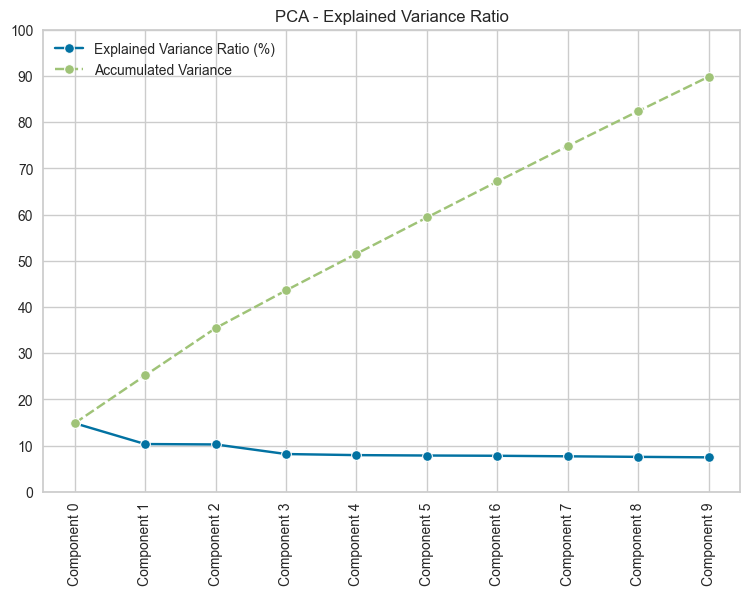

In [10]:
sns.set_style("whitegrid")

n_components = 10


def pca_components_analysis(df_pca, n_components):
    pca = PCA(n_components=n_components).fit(df_pca)

    ComponentsList = ["Component " + str(number)
                      for number in range(n_components)]
    dfExplVarRatio = pd.DataFrame(
        data=np.round(100 * pca.explained_variance_ratio_, 3),
        index=ComponentsList,
        columns=['Explained Variance Ratio (%)'])

    dfExplVarRatio['Accumulated Variance'] = (
        dfExplVarRatio['Explained Variance Ratio (%)'].cumsum()
    )
    PercentageOfDataExplained = (
        dfExplVarRatio['Explained Variance Ratio (%)'].sum()
    )

    print(dfExplVarRatio)
    print(
        f"\n* The {n_components} components"
        f" explain {round(PercentageOfDataExplained, 2)}% of the data \n")

    plt.figure(figsize=(9, 6))
    sns.lineplot(data=dfExplVarRatio, marker="o")
    plt.xticks(rotation=90)
    plt.yticks(np.arange(0, 110, 10))
    plt.title("PCA - Explained Variance Ratio")
    plt.show()


pca_components_analysis(df_pca=df_pca, n_components=n_components)

## Elbow & Silhouette Analysis

Determine the optimal number of clusters using the PCA-transformed data.

In [11]:
# Transform data through encoding + scaling + PCA (everything except KMeans)
pipeline_cluster = PipelineCluster()
pipeline_analysis = Pipeline(pipeline_cluster.steps[:-1])
df_analysis = pipeline_analysis.fit_transform(df)

print(f"Shape after PCA: {df_analysis.shape}")

Shape after PCA: (14701, 11)


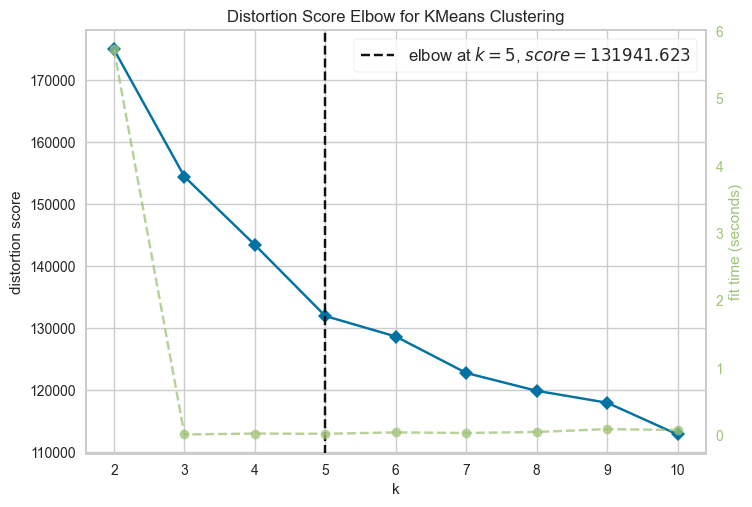

Optimal k (elbow): 5


In [12]:
visualizer = KElbowVisualizer(
    KMeans(random_state=0), k=(2, 11), force_model=True
)
visualizer.fit(df_analysis)
visualizer.show()
print(f"Optimal k (elbow): {visualizer.elbow_value_}")

=== Average Silhouette Score for different number of clusters ===


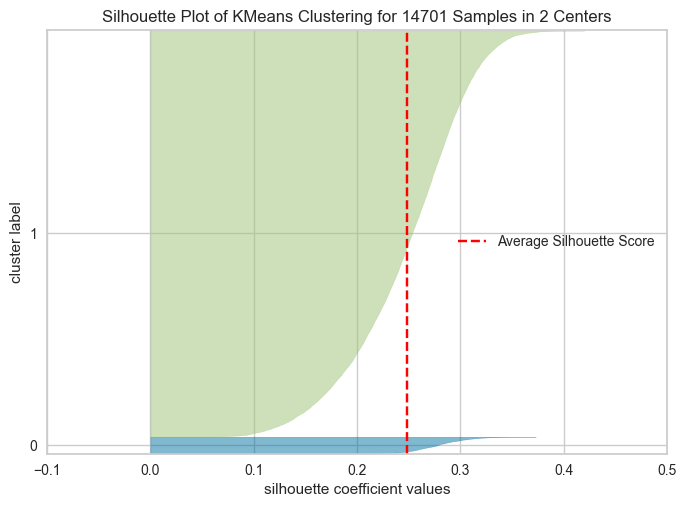

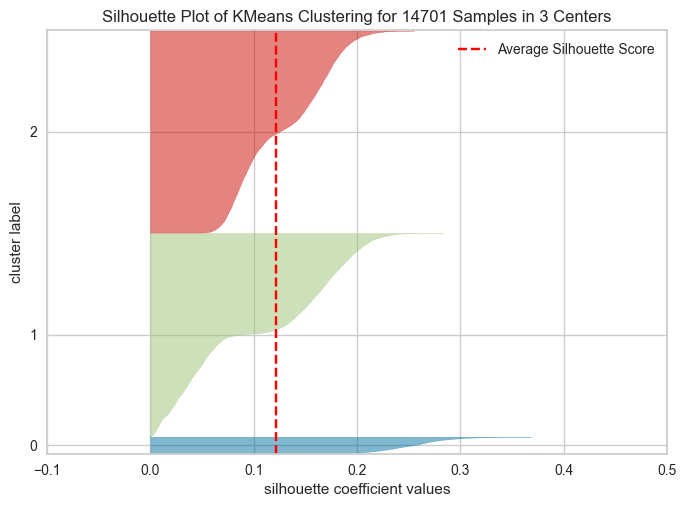

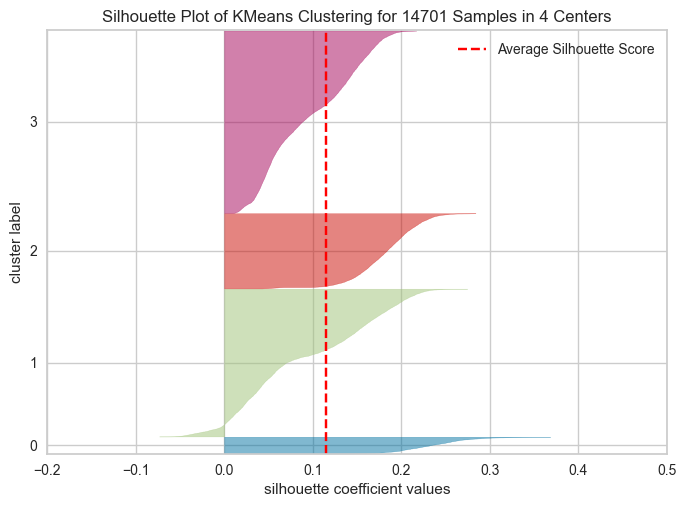

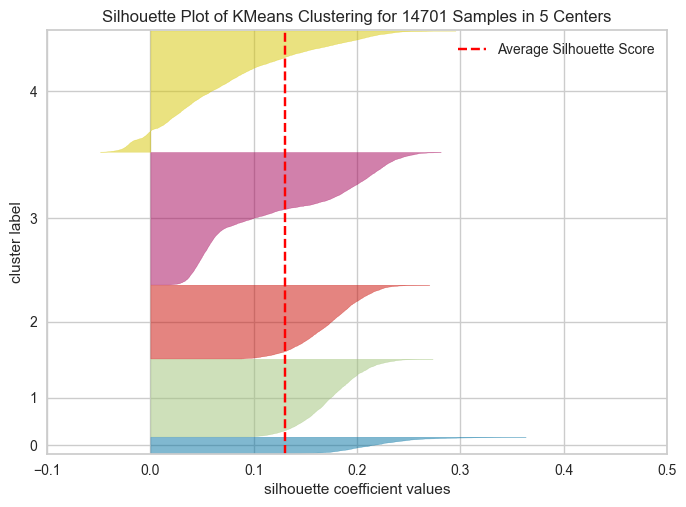

In [13]:
n_cluster_start, n_cluster_stop = 2, 5

print("=== Average Silhouette Score for different number of clusters ===")

for n in range(n_cluster_start, n_cluster_stop + 1):
    km = KMeans(n_clusters=n, random_state=0)
    visualizer = SilhouetteVisualizer(
        km, colors="yellowbrick", force_model=True
    )
    visualizer.fit(df_analysis)
    visualizer.show()
    print(f"\n")

## Fit Cluster Pipeline

Quick recap of our data for training the cluster pipeline

In [14]:
X = df.copy()
print(X.shape)
X.head(3)

(14701, 11)


,job_title,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score
0,Machine Learning Engineer,EX,PT,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2
1,Principal Data Scientist,EX,PT,South Korea,L,Argentina,50,PhD,11,Consulting,8.0
2,Research Scientist,SE,CT,Singapore,S,Singapore,100,Associate,6,Energy,7.9


Fit cluster pipeline

In [15]:
pipeline_cluster = PipelineCluster()
pipeline_cluster.fit(X)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


## Add cluster predictions to dataset

We add a column `Clusters` (with the cluster pipeline predictions) to the dataset

In [16]:
X['Clusters'] = pipeline_cluster['model'].labels_
print(X.shape)
X.head(3)

(14701, 12)


,job_title,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score,Clusters
0,Machine Learning Engineer,EX,PT,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2,1
1,Principal Data Scientist,EX,PT,South Korea,L,Argentina,50,PhD,11,Consulting,8.0,1
2,Research Scientist,SE,CT,Singapore,S,Singapore,100,Associate,6,Energy,7.9,1


* Clusters frequencies 
          proportion
Clusters            
1               0.48
2               0.48
0               0.04 




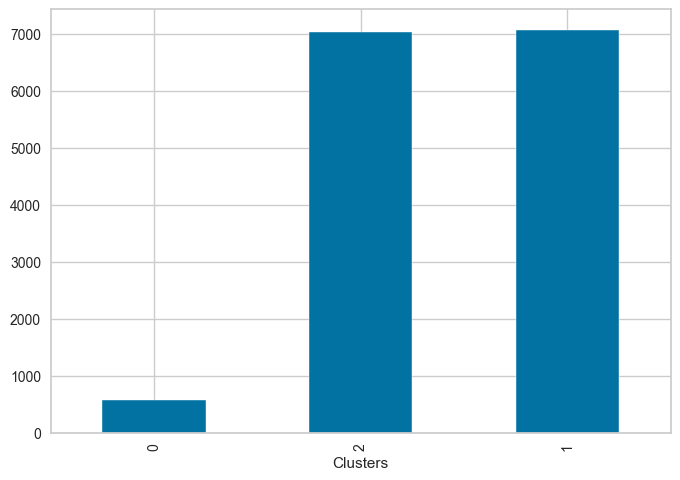

In [17]:
print(f"* Clusters frequencies \n{
    X['Clusters'].value_counts(normalize=True).to_frame().round(2)} \n\n")
X['Clusters'].value_counts().sort_values().plot(kind='bar')
plt.show()

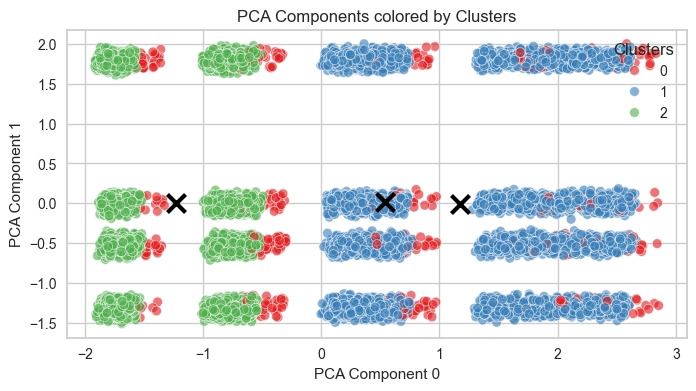

In [18]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 4))
sns.scatterplot(x=df_analysis[:, 0], y=df_analysis[:, 1],
                hue=X['Clusters'], palette='Set1', alpha=0.6)
plt.scatter(
    x=pipeline_cluster['model'].cluster_centers_[:, 0],
    y=pipeline_cluster['model'].cluster_centers_[:, 1],
    marker="x", s=169, linewidths=3, color="black")
plt.xlabel("PCA Component 0")
plt.ylabel("PCA Component 1")
plt.title("PCA Components colored by Clusters")
plt.show()

Visualization of the clusters in PCA space reveals that the 4-cluster K-Means model does not align with the natural 'islands' present in the data. Instead, the algorithm has partitioned the data into horizontal strata (slices). The presence of centroids in empty feature space further indicates that K-Means—which assumes spherical cluster shapes—is an inappropriate model for this specific data structure. The data would likely be better served by a density-based clustering algorithm like DBSCAN, which can recognize the individual islands as distinct groups.

We save the cluster predictions from this pipeline to use for comparison later.

In [19]:
cluster_predictions_with_all_variables = X['Clusters']
cluster_predictions_with_all_variables

0        1
1        1
2        1
3        1
4        2
        ..
14696    1
14697    1
14698    1
14699    1
14700    1
Name: Clusters, Length: 14701, dtype: int32

---

## Fit a classifier to explain clusters

We train a GradientBoostingClassifier where the target is the cluster label and the features are the original variables. This lets us identify which features best define each cluster.

We copy X to a DataFrame `df_clf`

In [20]:
df_clf = X.copy()
print(df_clf.shape)
df_clf.head(3)

(14701, 12)


,job_title,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score,Clusters
0,Machine Learning Engineer,EX,PT,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2,1
1,Principal Data Scientist,EX,PT,South Korea,L,Argentina,50,PhD,11,Consulting,8.0,1
2,Research Scientist,SE,CT,Singapore,S,Singapore,100,Associate,6,Energy,7.9,1


Split Train and Test sets

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    df_clf.drop(['Clusters'], axis=1),
    df_clf['Clusters'],
    test_size=0.2,
    random_state=0
)

print(X_train.shape, X_test.shape)

(11760, 11) (2941, 11)


Create classifier pipeline

In [22]:
def PipelineClf2ExplainClusters():
    pipeline_base = Pipeline([
        ("OrdinalMappingEncoder", OrdinalMappingEncoder(mappings={
            'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
            'education_required': {
                'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
            'company_size': {'S': 0, 'M': 1, 'L': 2},
        })),

        ("OneHotEncoder", OneHotEncoder(
            variables=['employment_type'],
            drop_last=True)),

        ("FrequencyEncoder", CountFrequencyEncoder(
            encoding_method='frequency',
            variables=[
                'job_title', 'company_location',
                'employee_residence', 'industry'])),

        ("model", GradientBoostingClassifier(random_state=0)),
    ])
    return pipeline_base


PipelineClf2ExplainClusters()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


Fit the classifier to the training data

In [23]:
pipeline_clf_cluster = PipelineClf2ExplainClusters()
pipeline_clf_cluster.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


## Evaluate classifier performance on Train and Test Sets

In [24]:
print("--- Train Set ---")
print(classification_report(y_train, pipeline_clf_cluster.predict(X_train)))

print("--- Test Set ---")
print(classification_report(y_test, pipeline_clf_cluster.predict(X_test)))

--- Train Set ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       455
           1       1.00      1.00      1.00      5658
           2       1.00      1.00      1.00      5647

    accuracy                           1.00     11760
   macro avg       1.00      1.00      1.00     11760
weighted avg       1.00      1.00      1.00     11760

--- Test Set ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       128
           1       1.00      1.00      1.00      1426
           2       1.00      1.00      1.00      1387

    accuracy                           1.00      2941
   macro avg       1.00      1.00      1.00      2941
weighted avg       1.00      1.00      1.00      2941



## Assess the most important features that define a cluster

* Best features to define a cluster: ['experience_level', 'years_experience', 'company_location']


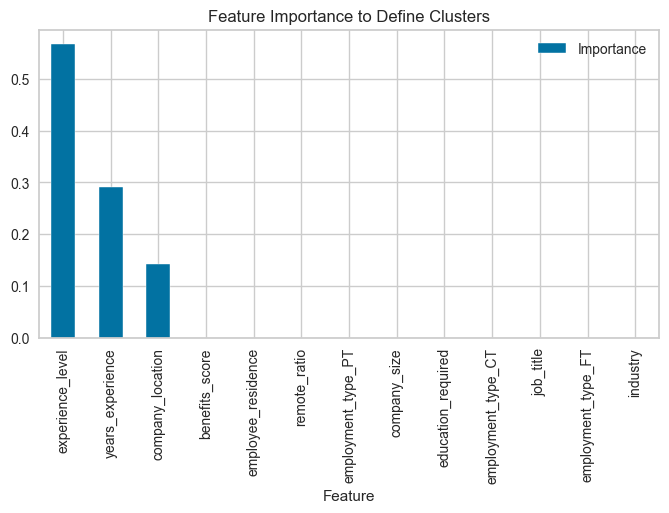

In [25]:
# after data cleaning and feature engineering, the feature space changes
# how many data cleaning and feature engineering steps does your pipeline have?
data_cleaning_feat_eng_steps = 3  # OrdinalMapping, OneHot, Frequency
columns_after_data_cleaning_feat_eng = (
    Pipeline(pipeline_clf_cluster.steps[:data_cleaning_feat_eng_steps])
    .transform(X_train)
    .columns
)

best_features = columns_after_data_cleaning_feat_eng.to_list()


# create DataFrame to display feature importance
df_feature_importance = (
    pd.DataFrame(data={
        'Feature': best_features,
        'Importance': pipeline_clf_cluster['model'].feature_importances_})
    .sort_values(by='Importance', ascending=False)
)

# Keep only features with above-average importance
mean_importance = df_feature_importance['Importance'].mean()
best_features = df_feature_importance[
    df_feature_importance['Importance'] >= mean_importance
]['Feature'].to_list()
# Change from >= mean to a smaller fraction of the mean, or a flat value
# Shows more features
best_features = df_feature_importance[
    df_feature_importance['Importance'] >= (mean_importance * 0.5)
]['Feature'].to_list()

print(f"* Best features to define a cluster: {best_features}")
df_feature_importance.plot(
    kind='bar', x='Feature', y='Importance', figsize=(8, 4))
plt.title("Feature Importance to Define Clusters")
plt.show()

We will store the `best_features` to use at a later stage.

In [26]:
best_features_pipeline_all_variables = best_features
best_features_pipeline_all_variables

['experience_level', 'years_experience', 'company_location']

---

# Cluster Analysis

Load a custom function to plot cluster distribution per variable (absolute and relative levels)

In [27]:
def cluster_distribution_per_variable(df, target):
    """
    The data should have 2 variables: the cluster predictions and
    the variable you want to analyse. We use plotly express to create 2 plots:
    Cluster distribution across the target.
    Relative presence of the target level in each cluster.
    """
    df_bar_plot = (
        df.groupby(['Clusters', target])
        .size().reset_index(name='Count')
    )
    df_bar_plot.columns = ['Clusters', target, 'Count']
    df_bar_plot[target] = df_bar_plot[target].astype('object')

    print(f"\n* Clusters distribution across {target} levels")
    fig = px.bar(df_bar_plot, x='Clusters', y='Count',
                 color=target, width=800, height=350)
    fig.update_layout(xaxis=dict(
        tickmode='array', tickvals=df['Clusters'].unique()))
    fig.show()

    df_relative = (
        df
        .groupby(['Clusters', target]).size()
        .unstack(fill_value=0)
        .apply(lambda x: 100 * x / x.sum(), axis=1)
        .stack()
        .reset_index(name='Relative Percentage (%)')
        .sort_values(by=['Clusters', target])
    )
    df_relative.columns = ['Clusters', target, 'Relative Percentage (%)']

    print(f"\n* Relative Percentage (%) of {target} in each cluster")
    fig = px.line(df_relative, x='Clusters', y='Relative Percentage (%)',
                  color=target, width=800, height=350)
    fig.update_layout(xaxis=dict(
        tickmode='array', tickvals=df['Clusters'].unique()))
    fig.update_traces(mode='markers+lines')
    fig.show()

Create a DataFrame that contains best features and Clusters Predictions since we want to analyse the patterns for each cluster.

In [28]:
df_cluster_profile = df_clf.copy()
df_cluster_profile = df_cluster_profile.filter(
    items=best_features + ['Clusters'], axis=1)
print(df_cluster_profile.shape)
df_cluster_profile.head(3)

(14701, 4)


,experience_level,years_experience,company_location,Clusters
0,EX,14,United Kingdom,1
1,EX,11,South Korea,1
2,SE,6,Singapore,1


We also want to analyse **SalaryBand** levels (Low / Mid / High) derived from `salary_usd`.

In [29]:
df_salary = pd.concat([
    pd.read_csv("outputs/datasets/cleaned/TrainSet.csv")[['salary_usd']],
    pd.read_csv("outputs/datasets/cleaned/TestSet.csv")[['salary_usd']]
], ignore_index=True)

q33, q67 = df_salary['salary_usd'].quantile([0.33, 0.67])
df_salary['SalaryBand'] = pd.cut(
    df_salary['salary_usd'],
    bins=[-np.inf, q33, q67, np.inf],
    labels=['Low', 'Mid', 'High']
).astype('object')

df_salary = df_salary.drop(columns=['salary_usd'])
df_salary.head(3)

,SalaryBand
0,High
1,High
2,Mid


## Cluster profile based on the best features

In [30]:
def DescriptionAllClusters(df, decimal_points=3):

    DescriptionAllClusters = pd.DataFrame(
        columns=df.drop(['Clusters'], axis=1).columns)
    for cluster in df.sort_values(by='Clusters')['Clusters'].unique():

        EDA_ClusterSubset = df.query(
            f"Clusters == {cluster}").drop(['Clusters'], axis=1)
        ClusterDescription = Clusters_IndividualDescription(
            EDA_ClusterSubset, cluster, decimal_points)
        DescriptionAllClusters = pd.concat(
            [DescriptionAllClusters, ClusterDescription], axis=0)

    return DescriptionAllClusters


def Clusters_IndividualDescription(EDA_ClusterSubset, cluster, decimal_points):
    ClusterDescription = pd.DataFrame()

    for column in EDA_ClusterSubset.columns:
        if EDA_ClusterSubset[column].dtype == 'object':
            description = (
                EDA_ClusterSubset[column]
                .value_counts(normalize=True)
                .head(3)
                .apply(lambda x: f"{100*x:.{decimal_points}f}%")
                .reset_index()
                .apply(lambda row: f"'{row.iloc[0]}': {row.iloc[1]} ", axis=1)
                .str.cat(sep=', ')
            )
            ClusterDescription[column] = [
                description if description else 'N/A'
            ]
        else:
            q25 = (
                EDA_ClusterSubset[column]
                .quantile(0.25)
                .round(decimal_points)
            )
            q75 = (
                EDA_ClusterSubset[column]
                .quantile(0.75)
                .round(decimal_points)
            )
            ClusterDescription[column] = [
                f"{q25} -- {q75}"
            ]

    ClusterDescription.insert(loc=0, column='Cluster', value=cluster)

    return ClusterDescription

In [31]:
pd.set_option('display.max_colwidth', None)
clusters_profile = DescriptionAllClusters(
    df=pd.concat([df_cluster_profile, df_salary], axis=1),
    decimal_points=0)
clusters_profile

,experience_level,years_experience,company_location,SalaryBand,Cluster
0,"'MI': 31% , 'EX': 30% , 'SE': 29%",3.0 -- 11.0,'India': 100%,"'Low': 93% , 'Mid': 7%",0.0
0,"'SE': 50% , 'EX': 50%",7.0 -- 15.0,"'Israel': 6% , 'Germany': 6% , 'Singapore': 6%","'High': 66% , 'Mid': 30% , 'Low': 4%",1.0
0,"'MI': 51% , 'EN': 49%",1.0 -- 3.0,"'Switzerland': 6% , 'United States': 6% , 'United Kingdom': 6%","'Low': 57% , 'Mid': 40% , 'High': 3%",2.0


Using PCA to blend all features into balanced components, the clusters show clear salary separation:

**Cluster 0 (The India Segment — ~4%):** India-centric roles (company_location: 100% India). Mixed experience levels (MI 31%, EX 30%, SE 29%), years_experience 3–11. Salary band is 93% "Low", 7% "Mid". Geography remains the strongest penalty — when employee and company are both in India, salaries are almost always low regardless of experience level.

**Cluster 1 (Senior Professionals — ~48%):** SE (50%) and EX (50%) level, 7–15 years experience. Distributed across developed markets (Israel 6%, Germany 6%, Singapore 6%). Salary is 66% "High", 30% "Mid", 4% "Low". Experience drives these professionals into premium pay.

**Cluster 2 (Junior/Entry — ~48%):** MI (51%) and EN (49%) level, 1–3 years experience. Also in developed markets (Switzerland 6%, United States 6%, United Kingdom 6%). Salary is 57% "Low", 40% "Mid", 3% "High". Early-career professionals earning less, as expected.

**Key insight:** PCA revealed that experience (PC1 = 48% of variance) is the dominant axis, while geography (PC2–PC3) creates the secondary separation.

## Clusters distribution across SalaryBand levels & Relative Percentage of SalaryBand in each cluster

In [32]:
df_cluster_vs_salary = df_salary.copy()
df_cluster_vs_salary['Clusters'] = X['Clusters']
cluster_distribution_per_variable(df=df_cluster_vs_salary, target='SalaryBand')


* Clusters distribution across SalaryBand levels



* Relative Percentage (%) of SalaryBand in each cluster


The salary distribution confirms three distinct market segments:

**Segment A — Emerging Market Discount (Cluster 0):** Low salaries driven by India-centric geography. A clear cost-of-living penalty.

**Segment B — Senior Premium (Cluster 1):** High salaries driven by 7+ years of experience in developed markets. Experience is the differentiator.

**Segment C — Junior Pipeline (Cluster 2):** Lower salaries for 1–3 years experience, even in developed markets. These professionals are on an upward trajectory.

**Conclusion:** The AI salary market is shaped by two forces: **geography** (emerging vs developed) and **experience** (junior vs senior). PCA was essential to reveal the experience axis — without it, geography dominated and all developed-market clusters looked identical.

**Final Study Summary & Conclusion**

The Story: We started with all 11 features and used PCA to let the data reveal its natural structure. PCA compressed the encoded features into balanced components, preventing any single feature group from dominating.

The Result: Three meaningful market segments emerged with clear salary separation — experience (PC1) emerged as the dominant axis, and geography (PC2–PC3) created the secondary split.

**Key Findings:**
1. **Experience is the dominant axis** (PC1 = 48% variance) when features are balanced via PCA
2. **Geography creates a secondary split** — emerging vs developed markets
3. **Job title, industry, skills, and education** have no significant influence on AI salary segmentation
4. The AI salary market operates as a **two-factor system**: geography × experience

---

# Pipeline Summary

The final cluster pipeline uses 11 features with PCA to produce 3 meaningful market segments.

**Pipeline:** Encoding → StandardScaler → PCA(0.95) → KMeans(k=3)

Key design decisions:
- **Removed `SmartCorrelatedSelection`** — it was dropping `years_experience` (correlated with `experience_level`), but PCA handles this naturally by compressing them into PC1
- **PCA with `n_components=0.95`** — auto-selects components explaining 95% of variance, ensuring experience gets equal weight alongside geography
- **3 clusters** — validated by elbow/silhouette analysis

| Cluster | Size | Profile | Salary |
|---------|------|---------|--------|
| 0 | ~4% | India-centric, mixed experience | Low (93%) |
| 1 | ~48% | 7–15 yrs, SE/EX, developed markets | High (66%) |
| 2 | ~48% | 1–3 yrs, MI/EN, developed markets | Low (57%) / Mid (40%) |

---

# Save Pipeline and Artifacts

Saved pipeline_cluster.pkl to outputs/ml_pipeline/cluster_analysis/v1
Saved TrainSet.csv to outputs/ml_pipeline/cluster_analysis/v1
Saved clusters_profile.csv to outputs/ml_pipeline/cluster_analysis/v1


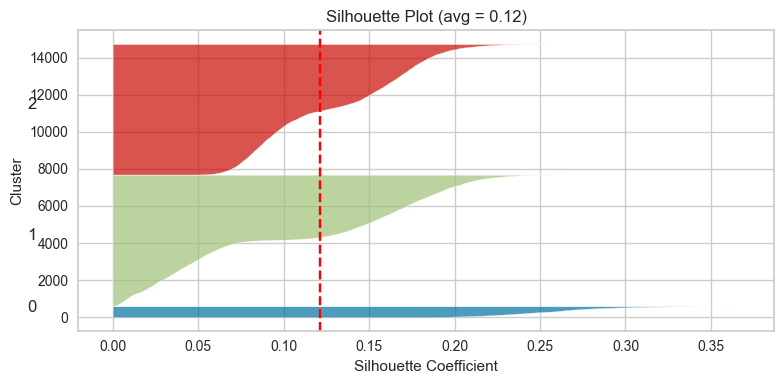

Saved clusters_silhouette.png to outputs/ml_pipeline/cluster_analysis/v1


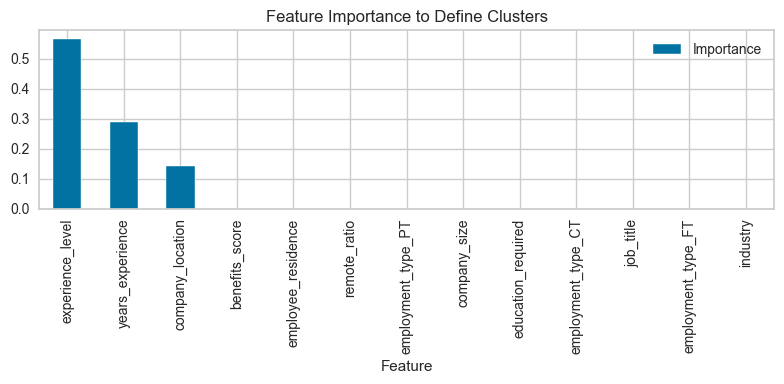

Saved features_define_cluster.png to outputs/ml_pipeline/cluster_analysis/v1


In [33]:
version = "v1"
output_dir = f"outputs/ml_pipeline/cluster_analysis/{version}"
os.makedirs(output_dir, exist_ok=True)

# Save the fitted cluster pipeline
joblib.dump(pipeline_cluster, f"{output_dir}/pipeline_cluster.pkl")
print(f"Saved pipeline_cluster.pkl to {output_dir}")

# Save the TrainSet (features used for clustering)
df.to_csv(f"{output_dir}/TrainSet.csv", index=False)
print(f"Saved TrainSet.csv to {output_dir}")

# Save the cluster profile
clusters_profile.to_csv(f"{output_dir}/clusters_profile.csv", index=False)
print(f"Saved clusters_profile.csv to {output_dir}")

# Save the silhouette plot
pipeline_no_kmeans = Pipeline(pipeline_cluster.steps[:-1])
X_pca = pipeline_no_kmeans.transform(df)
labels = pipeline_cluster['model'].labels_

fig, ax = plt.subplots(figsize=(8, 4))
silhouette_avg = silhouette_score(X_pca, labels)
sample_silhouette_values = silhouette_samples(X_pca, labels)

y_lower = 10
for i in sorted(set(labels)):
    ith_cluster_values = sample_silhouette_values[labels == i]
    ith_cluster_values.sort()
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i
    ax.fill_betweenx(
        np.arange(y_lower, y_upper), 0,
        ith_cluster_values, alpha=0.7
    )
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color="red", linestyle="--")
ax.set_title(
    f"Silhouette Plot (avg = {silhouette_avg:.2f})"
)
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
plt.tight_layout()
fig.savefig(
    f"{output_dir}/clusters_silhouette.png", dpi=150
)
plt.show()
print(f"Saved clusters_silhouette.png to {output_dir}")

# Save the feature importance plot
fig_imp, ax_imp = plt.subplots(figsize=(8, 4))
df_feature_importance.plot(
    kind='bar', x='Feature', y='Importance', ax=ax_imp
)
ax_imp.set_title("Feature Importance to Define Clusters")
plt.tight_layout()
fig_imp.savefig(
    f"{output_dir}/features_define_cluster.png", dpi=150
)
plt.show()
print(
    f"Saved features_define_cluster.png to {output_dir}"
)